In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load data
df = pd.read_csv('C:/Users/ADMIN/Downloads/combined_daily_weather_dataset.csv')
df.head()

,date,temperature,wind_speed,wind_direction,precipitation,humidity,dew_point,cloud_cover,surface_pressure,temp_max,temp_min
0,1947-01-01,8.079167,8.1,56,0.0,59.041667,-0.116667,33.458333,901.016667,16.9,0.9
1,1947-01-02,7.845833,7.3,55,0.0,52.416667,-1.975000,59.708333,899.016667,16.7,0.7
2,1947-01-03,8.575000,8.1,55,0.0,55.375000,-0.220833,99.750000,899.004167,16.2,4.0
3,1947-01-04,7.629167,5.8,51,9.5,82.500000,4.754167,84.583333,899.279167,9.6,5.2
4,1947-01-05,6.229167,4.2,45,15.6,84.666667,3.820833,73.625000,899.758333,10.4,2.5


In [3]:
# Remove 'temp_max' and 'temp_min' since we already have 'temperature'
df = df.drop(columns=['temp_max', 'temp_min'])

# Handle wind_direction with sine and cosine transformation
df['wind_direction_sin'] = np.sin(np.radians(df['wind_direction']))
df['wind_direction_cos'] = np.cos(np.radians(df['wind_direction']))

# Drop the original wind_direction column
df = df.drop(columns=['wind_direction'])

# Handle date column (if exists) - Convert to datetime and extract year, month, day
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])  # Convert date to datetime
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df = df.drop(columns=['date'])  # Drop the original date column

In [4]:
df.head()

,temperature,wind_speed,precipitation,humidity,dew_point,cloud_cover,surface_pressure,wind_direction_sin,wind_direction_cos,year,month,day
0,8.079167,8.1,0.0,59.041667,-0.116667,33.458333,901.016667,0.829038,0.559193,1947,1,1
1,7.845833,7.3,0.0,52.416667,-1.975000,59.708333,899.016667,0.819152,0.573576,1947,1,2
2,8.575000,8.1,0.0,55.375000,-0.220833,99.750000,899.004167,0.819152,0.573576,1947,1,3
3,7.629167,5.8,9.5,82.500000,4.754167,84.583333,899.279167,0.777146,0.629320,1947,1,4
4,6.229167,4.2,15.6,84.666667,3.820833,73.625000,899.758333,0.707107,0.707107,1947,1,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28588 entries, 0 to 28587
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temperature         28588 non-null  float64
 1   wind_speed          28588 non-null  float64
 2   precipitation       28588 non-null  float64
 3   humidity            28588 non-null  float64
 4   dew_point           28588 non-null  float64
 5   cloud_cover         28588 non-null  float64
 6   surface_pressure    28588 non-null  float64
 7   wind_direction_sin  28588 non-null  float64
 8   wind_direction_cos  28588 non-null  float64
 9   year                28588 non-null  int32  
 10  month               28588 non-null  int32  
 11  day                 28588 non-null  int32  
dtypes: float64(9), int32(3)
memory usage: 2.3 MB


In [6]:
df.describe()

,temperature,wind_speed,precipitation,humidity,dew_point,cloud_cover,surface_pressure,wind_direction_sin,wind_direction_cos,year,month,day
count,28588.000000,28588.000000,28588.000000,28588.000000,28588.000000,28588.000000,28588.000000,28588.000000,28588.000000,28588.000000,28588.000000,28588.000000
mean,16.642088,8.050479,4.828960,66.204924,9.338152,40.123742,895.524764,0.688370,0.462481,1985.635756,6.507905,15.726109
std,6.568975,2.076457,13.904608,15.806082,7.371016,32.051830,3.846612,0.448081,0.333903,22.595235,3.452749,8.800930
min,-0.429167,2.500000,0.000000,13.791667,-13.229167,0.000000,879.025000,-1.000000,-1.000000,1947.000000,1.000000,1.000000
25%,10.762500,6.700000,0.000000,56.375000,3.558333,10.322917,892.666667,0.754710,0.453990,1966.000000,4.000000,8.000000
50%,17.487500,7.700000,0.100000,66.125000,7.675000,34.291667,895.900000,0.819152,0.559193,1986.000000,7.000000,16.000000
75%,22.458333,9.000000,3.400000,79.291667,16.695833,67.427083,898.525000,0.866025,0.629320,2005.000000,10.000000,23.000000
max,31.754167,26.100000,253.400000,98.666667,23.904167,100.000000,905.925000,1.000000,1.000000,2025.000000,12.000000,31.000000


In [7]:
df.isnull().sum()

temperature           0
wind_speed            0
precipitation         0
humidity              0
dew_point             0
cloud_cover           0
surface_pressure      0
wind_direction_sin    0
wind_direction_cos    0
year                  0
month                 0
day                   0
dtype: int64

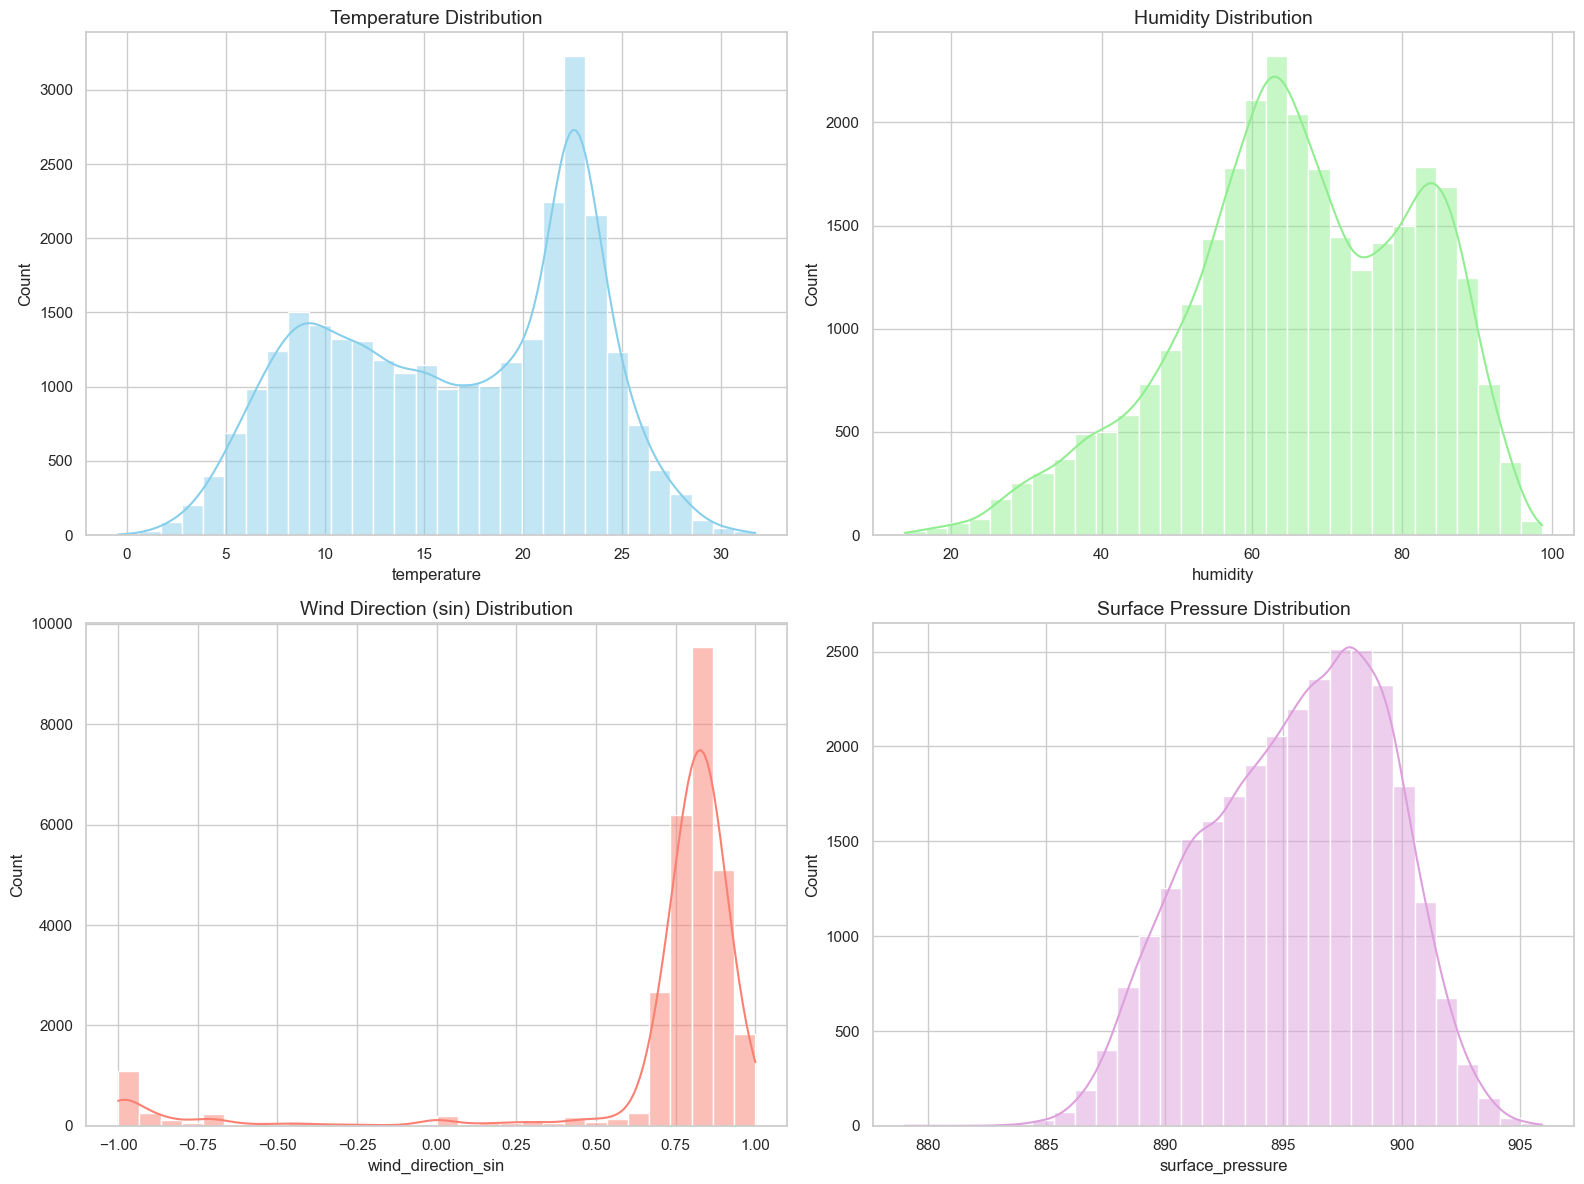

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")
plt.figure(figsize=(16, 12))

# Plot 1: Temperature Distribution
plt.subplot(2, 2, 1)
sns.histplot(df['temperature'], kde=True, bins=30, color='skyblue')
plt.title('Temperature Distribution', fontsize=14)

# Plot 2: Humidity Distribution
plt.subplot(2, 2, 2)
sns.histplot(df['humidity'], kde=True, bins=30, color='lightgreen')
plt.title('Humidity Distribution', fontsize=14)

# Plot 3: Wind Direction (sin) Distribution
plt.subplot(2, 2, 3)
sns.histplot(df['wind_direction_sin'], kde=True, bins=30, color='salmon')
plt.title('Wind Direction (sin) Distribution', fontsize=14)

# Plot 4: Surface Pressure Distribution (Optional)
plt.subplot(2, 2, 4)
sns.histplot(df['surface_pressure'], kde=True, bins=30, color='plum')
plt.title('Surface Pressure Distribution', fontsize=14)

plt.tight_layout()
plt.show()

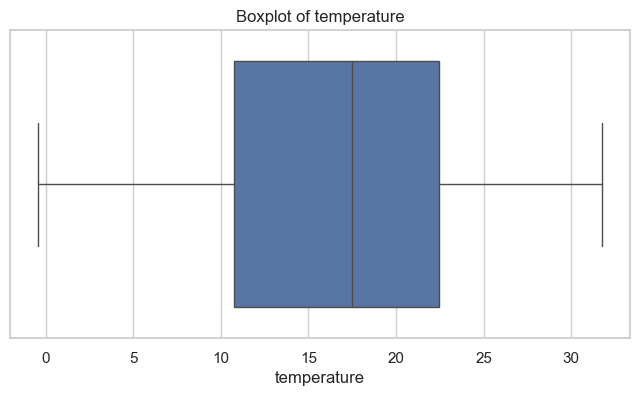

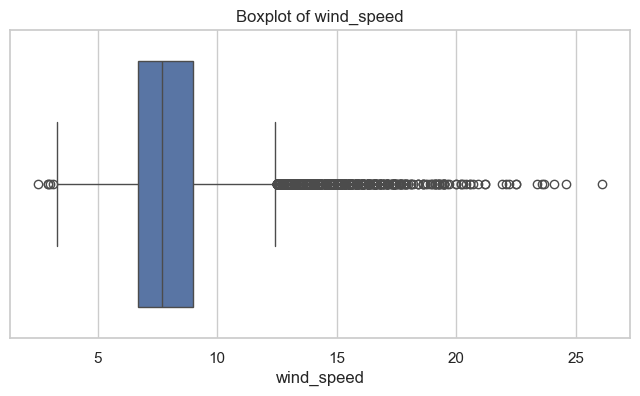

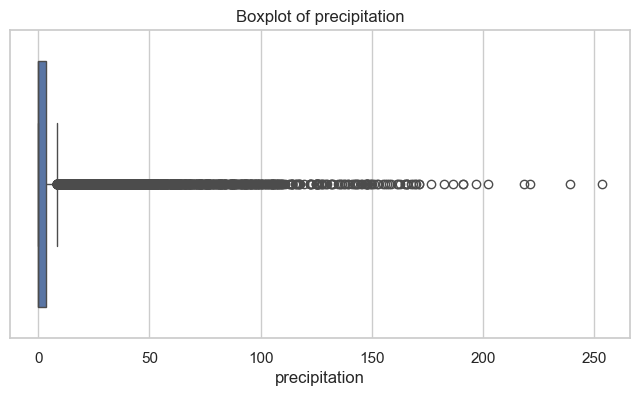

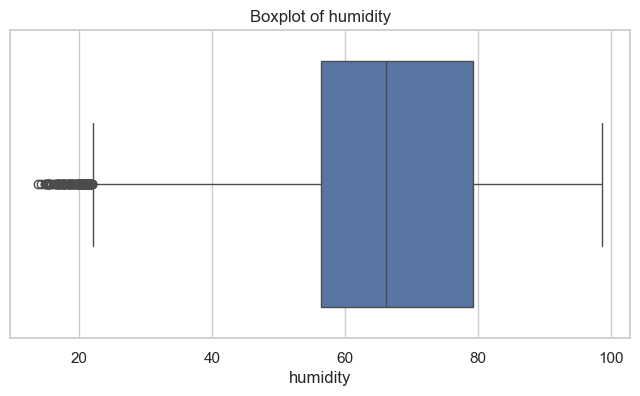

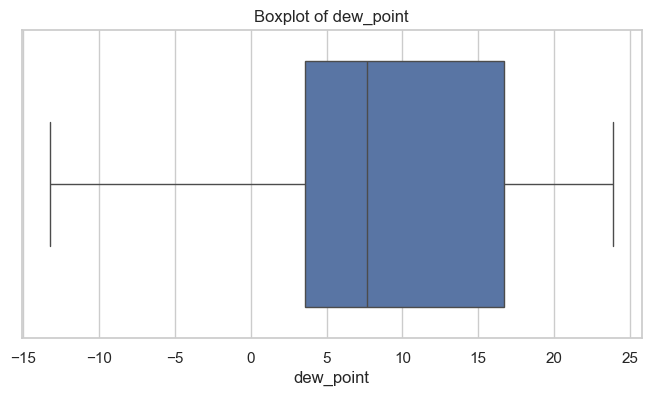

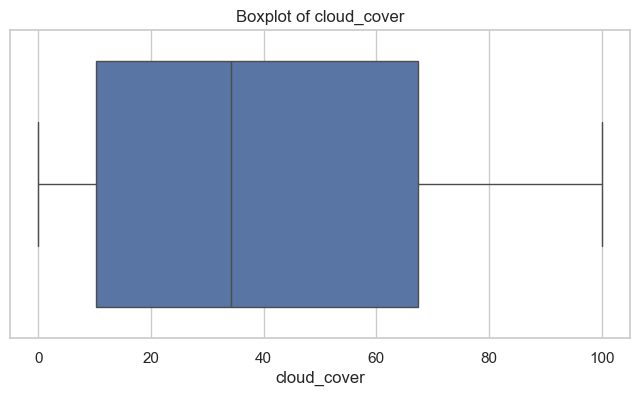

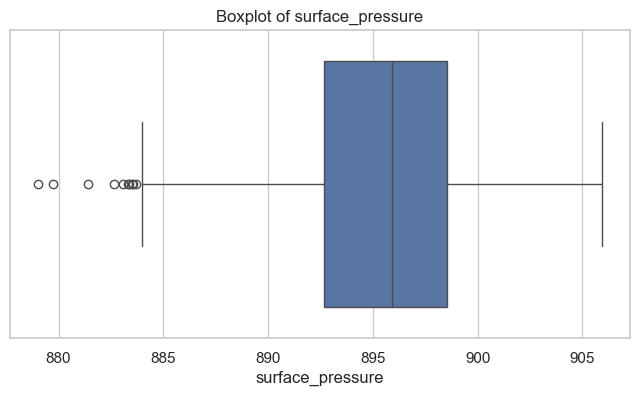

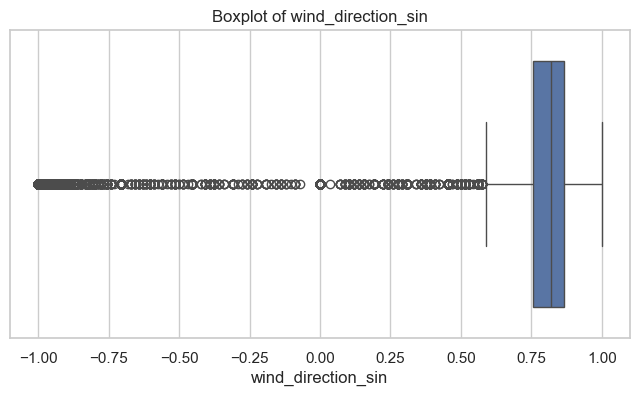

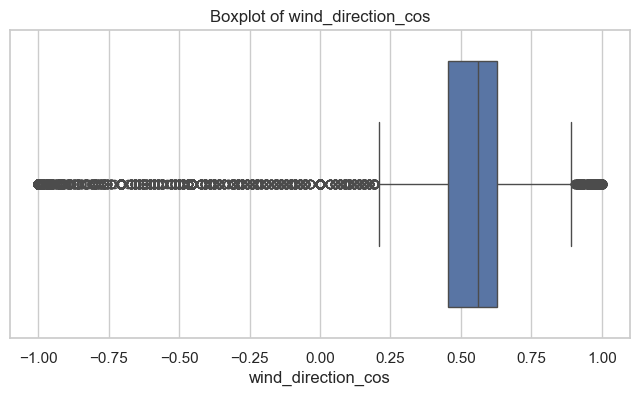

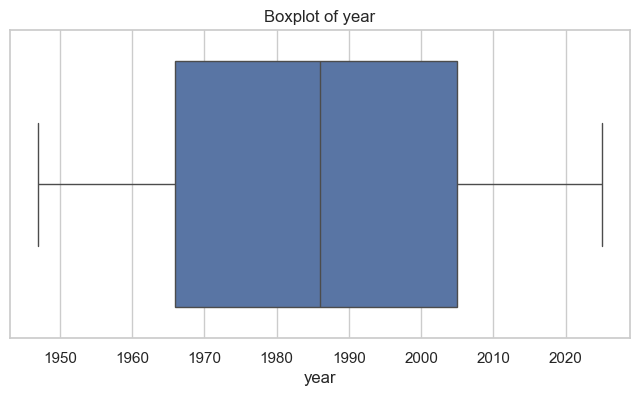

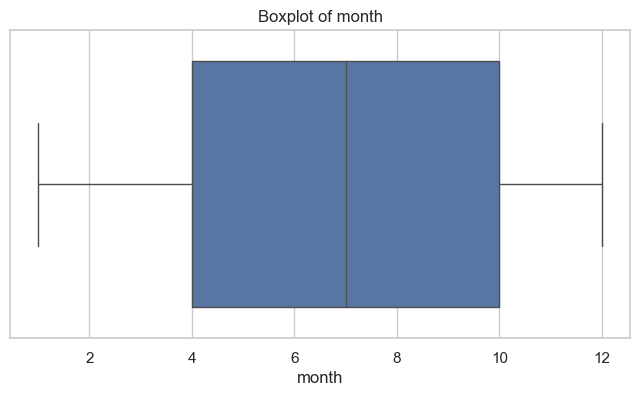

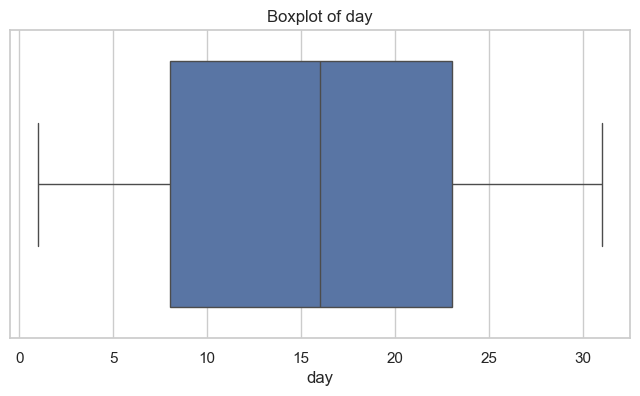

In [9]:
# Select all numeric columns from the dataframe
numeric_cols = df.select_dtypes(include=['number']).columns

# Plot boxplots for each numeric column
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])  # Create a boxplot for each numeric column
    plt.title(f'Boxplot of {col}')
    plt.show()


In [10]:
# Define the features with outliers
features = ['precipitation', 'wind_direction_sin', 'wind_direction_cos', 
            'wind_speed', 'humidity', 'surface_pressure']

# Function to cap outliers using IQR
def cap_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

# Apply the outlier capping to each feature in the list
for col in features:
    df[col] = cap_outliers_iqr(df[col])

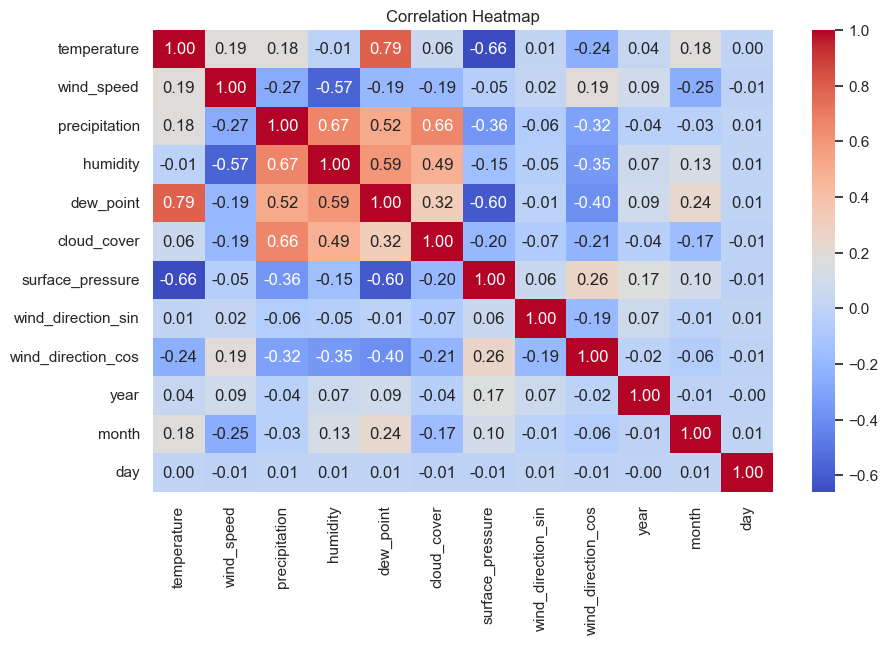

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

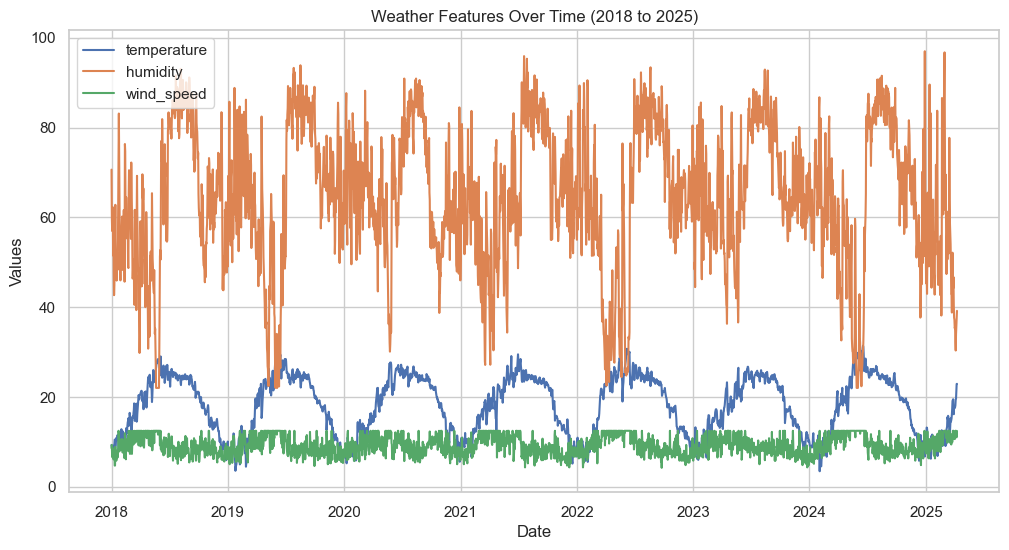

In [12]:
# Create a copy of the original dataframe
df_copy = df.copy()

# Combine day, month, and year to form a datetime column in the copy
df_copy['date'] = pd.to_datetime(df_copy[['year', 'month', 'day']])

# Filter the data for the last 5–7 years (you can adjust the start_year as needed)
start_year = 2018  # Adjust this year to match the last 5-7 years range
end_year = 2025  # Adjust to the current year
df_filtered = df_copy[(df_copy['date'].dt.year >= start_year) & (df_copy['date'].dt.year <= end_year)]

# Plot the features for the last 5–7 years
plt.figure(figsize=(12, 6))
for col in ['temperature', 'humidity', 'wind_speed']:  # Adjust as needed
    plt.plot(df_filtered['date'], df_filtered[col], label=col)
plt.xlabel('Date')
plt.ylabel('Values')
plt.title(f'Weather Features Over Time ({start_year} to {end_year})')
plt.legend()
plt.show()

In [13]:
# Define features (X) and target features (y)
target_features = ['temperature', 'wind_speed', 'precipitation', 'humidity', 'dew_point', 'cloud_cover', 'surface_pressure']
X = df.drop(columns=target_features)

# Ensure only numeric columns are used
X = X.select_dtypes(include=[np.number])

# Standardize the features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Store results for each feature
results = []

trained_models = {}


# Train and evaluate the model for each target feature
for target in target_features:
    # Define the target variable
    y = df[target]
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    
    # Initialize RandomForestRegressor model
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    
    # Train the model
    rf.fit(X_train, y_train)

    trained_models[target] = rf

    
    # Make predictions
    y_pred = rf.predict(X_test)
    
    # Calculate performance metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Store the results
    results.append([target, mae, mse, rmse, r2])

In [14]:
# Convert results to a DataFrame for better readability
results_df = pd.DataFrame(results, columns=['Feature', 'MAE', 'MSE', 'RMSE', 'R2 Score'])

# Display the results
results_df

,Feature,MAE,MSE,RMSE,R2 Score
0,temperature,0.934034,1.557027,1.247809,0.963892
1,wind_speed,1.059391,1.844567,1.358148,0.449885
2,precipitation,1.704913,5.993969,2.448258,0.398574
3,humidity,5.432068,54.203110,7.362276,0.781485
4,dew_point,1.447939,3.881059,1.970040,0.929255
5,cloud_cover,20.606871,669.188013,25.868669,0.345561
6,surface_pressure,1.313442,2.840766,1.685457,0.805888


In [15]:
# Step 1: Generate next 7 dates
from datetime import timedelta


last_date = df[['year', 'month', 'day']].iloc[-1]
start_date = pd.Timestamp(year=last_date['year'], month=last_date['month'], day=last_date['day']) + timedelta(days=1)
future_dates = [start_date + timedelta(days=i) for i in range(7)]

# Step 2: Create empty DataFrame with the same feature columns as used in training
future_df = pd.DataFrame(columns=X.columns)

# Step 3: Fill in the values
for i, date in enumerate(future_dates):
    row = {}
    for col in X.columns:
        if col == 'year':
            row[col] = date.year
        elif col == 'month':
            row[col] = date.month
        elif col == 'day':
            row[col] = date.day
        elif col in ['wind_direction_sin', 'wind_direction_cos']:
            row[col] = 0  # Assuming no directional bias
        else:
            row[col] = df[col].mean()  # Use mean of original data for rest
    future_df.loc[i] = row

# Step 4: Scale features
future_scaled = scaler_X.transform(future_df)

# Step 5: Predict
future_predictions = {}
for target in target_features:
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_scaled, df[target])
    preds = model.predict(future_scaled)
    future_predictions[target] = preds

# Step 6: Combine output
forecast_df = pd.DataFrame({
    'date': future_dates
})
for target in target_features:
    forecast_df[target] = future_predictions[target]

forecast_df

,date,temperature,wind_speed,precipitation,humidity,dew_point,cloud_cover,surface_pressure
0,2025-04-09,20.487042,10.3720,6.297,45.968333,5.760333,46.965417,899.254167
1,2025-04-10,20.562375,10.5010,6.212,46.763333,5.571542,47.115000,899.250167
2,2025-04-11,20.287208,10.5590,6.372,45.977500,5.682958,49.129167,899.441625
3,2025-04-12,20.469750,10.5540,6.527,45.427500,5.788042,53.614583,899.368208
4,2025-04-13,20.439375,10.5865,6.529,45.554167,6.387417,55.160833,899.251792
5,2025-04-14,19.413208,10.5680,6.614,45.250417,7.226042,58.750000,899.018708
6,2025-04-15,19.082625,10.4055,6.686,44.747917,7.389875,65.294583,898.730917


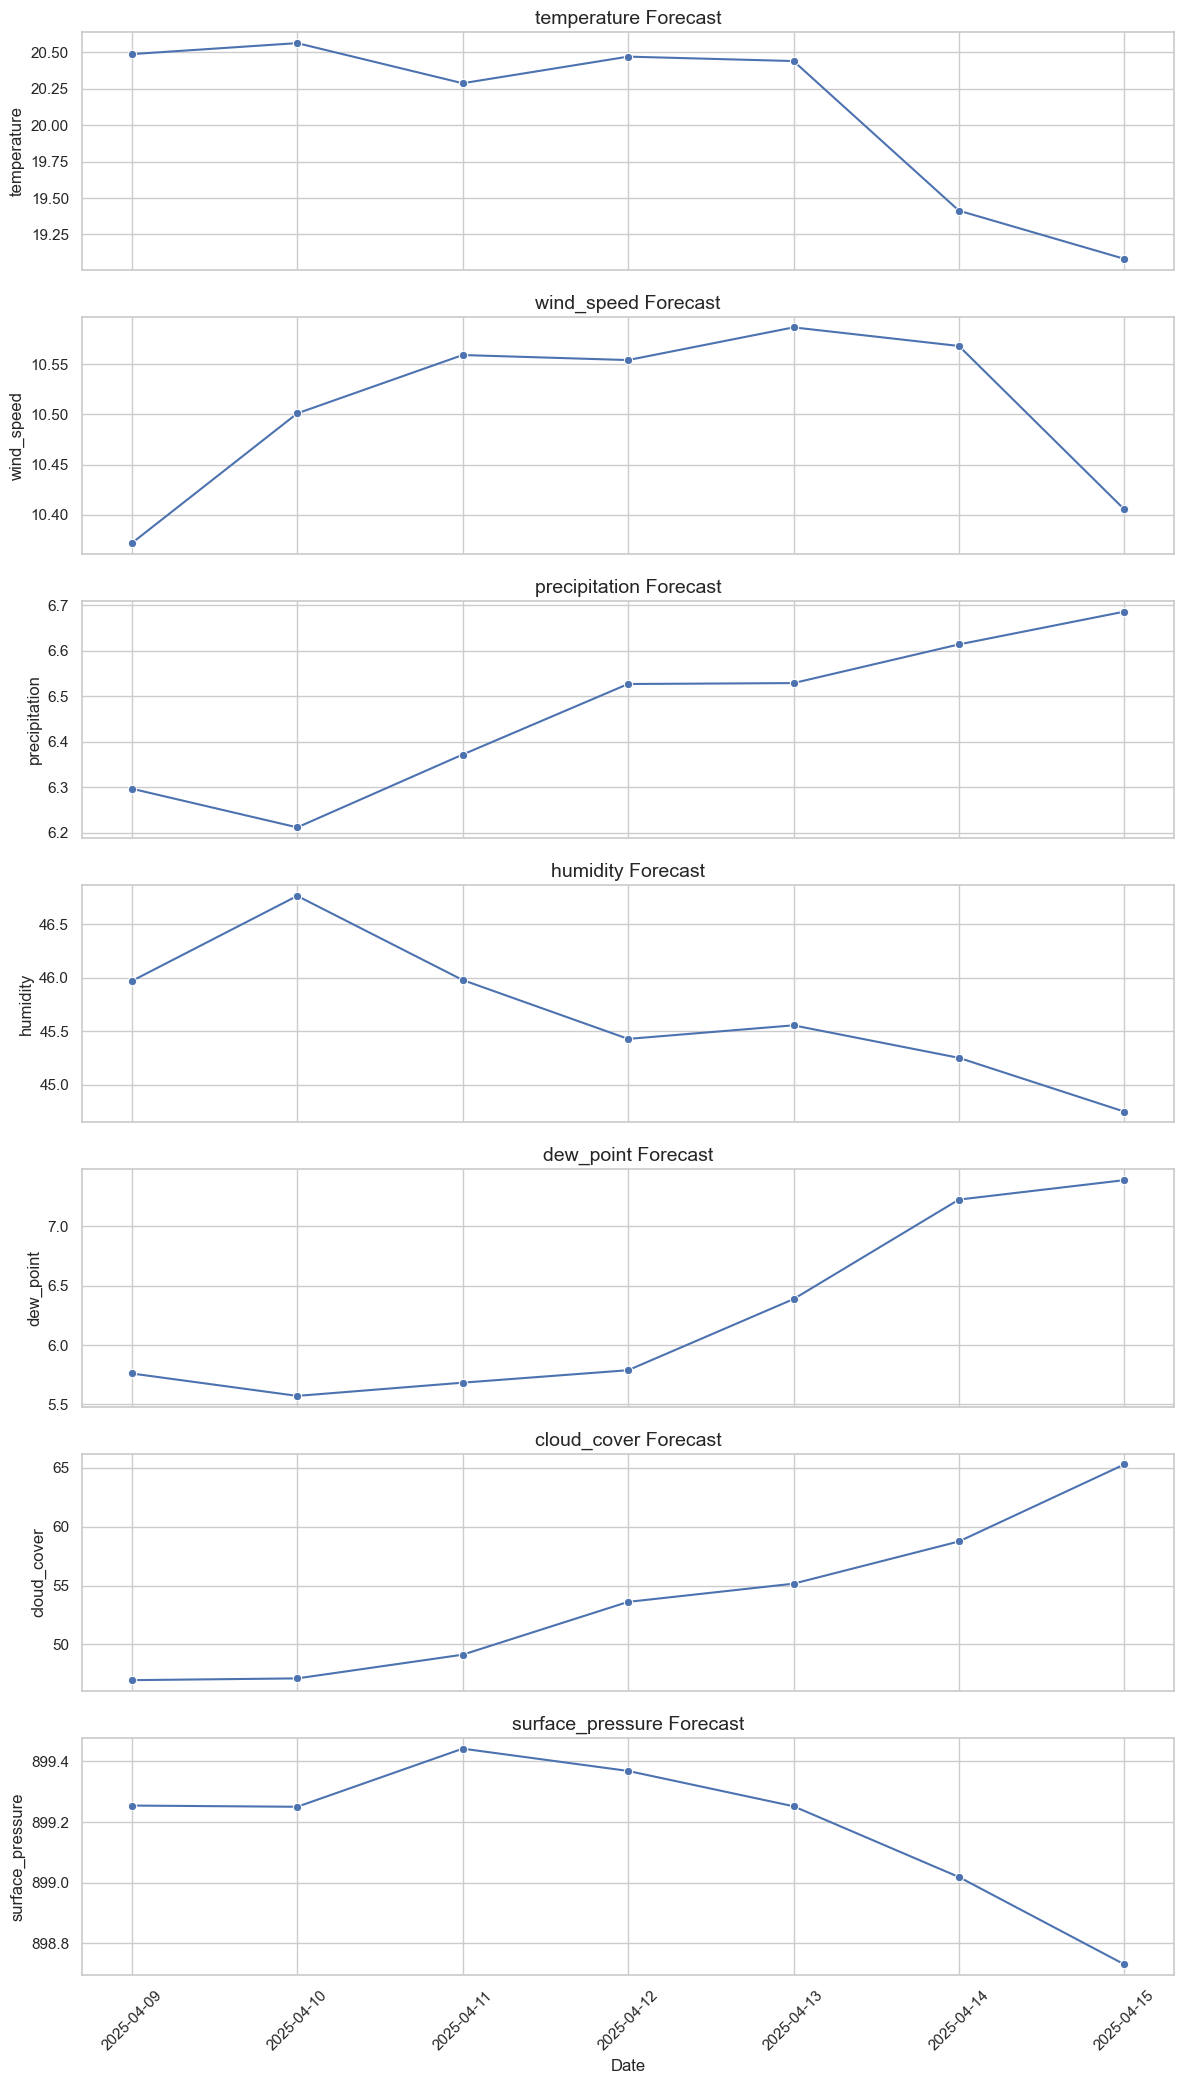

In [16]:
fig, axes = plt.subplots(len(target_features), 1, figsize=(12, 3 * len(target_features)), sharex=True)

for i, col in enumerate(target_features):
    sns.lineplot(x='date', y=col, data=forecast_df, ax=axes[i], marker='o')
    axes[i].set_title(f'{col} Forecast', fontsize=14)
    axes[i].set_ylabel(col)
    axes[i].grid(True)

plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

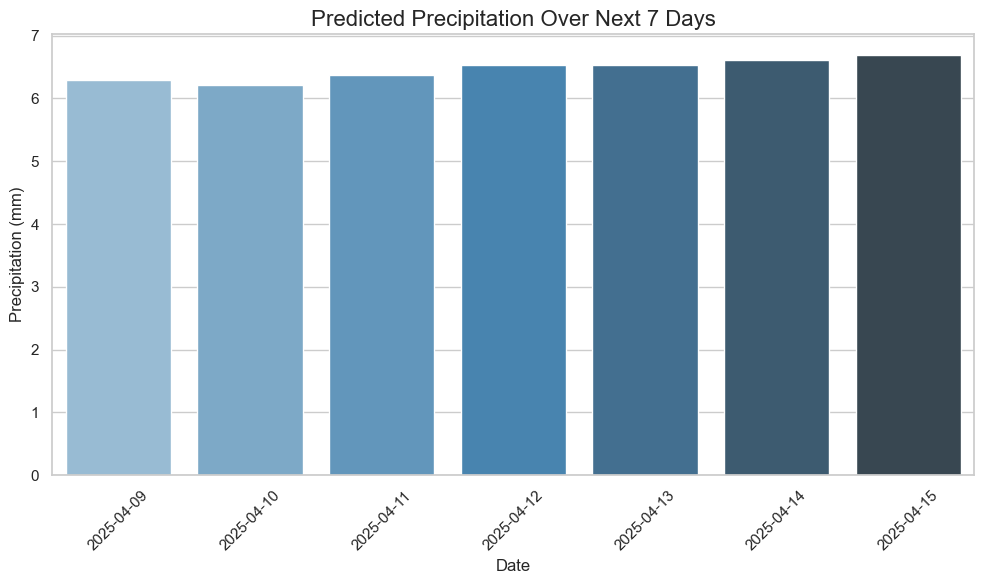

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(x='date', y='precipitation', hue='date', data=forecast_df, palette='Blues_d', legend=False)
plt.title('Predicted Precipitation Over Next 7 Days', fontsize=16)
plt.ylabel('Precipitation (mm)')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# Prediction vs Actual for 5 random samples
sample_df = df.copy().sample(n=5, random_state=42)

# Prepare the features from these samples
X_sample_raw = sample_df.drop(columns=target_features).select_dtypes(include=[np.number])
X_sample_scaled = scaler_X.transform(X_sample_raw)

print(f"{'Date':<12} | {'Target':<15} | {'Actual':>10} | {'Predicted':>10}")
print("-" * 56)

for idx, row in sample_df.iterrows():
    date_str = f"{int(row['year'])}-{int(row['month']):02d}-{int(row['day']):02d}"
    for i, col in enumerate(target_features):
        model = trained_models[col]
        pred = model.predict([X_sample_scaled[idx % 5]])[0]  # Safe indexing
        actual = row[col]
        print(f"{date_str:<12} | {col:<15} | {actual:>10.2f} | {pred:>10.2f}")

Date         | Target          |     Actual |  Predicted
--------------------------------------------------------
2006-04-28   | temperature     |      21.82 |      22.25
2006-04-28   | wind_speed      |       9.80 |       5.82
2006-04-28   | precipitation   |       0.00 |       7.96
2006-04-28   | humidity        |      35.67 |      89.56
2006-04-28   | dew_point       |       4.69 |      20.42
2006-04-28   | cloud_cover     |      13.62 |      89.49
2006-04-28   | surface_pressure |     895.10 |     889.72
1980-06-10   | temperature     |      26.50 |      21.68
1980-06-10   | wind_speed      |       9.90 |       9.66
1980-06-10   | precipitation   |       0.00 |       1.06
1980-06-10   | humidity        |      51.79 |      47.94
1980-06-10   | dew_point       |      15.17 |       8.82
1980-06-10   | cloud_cover     |       3.04 |      35.18
1980-06-10   | surface_pressure |     891.98 |     894.46
1956-07-20   | temperature     |      22.28 |      18.67
1956-07-20   | wind_speed    

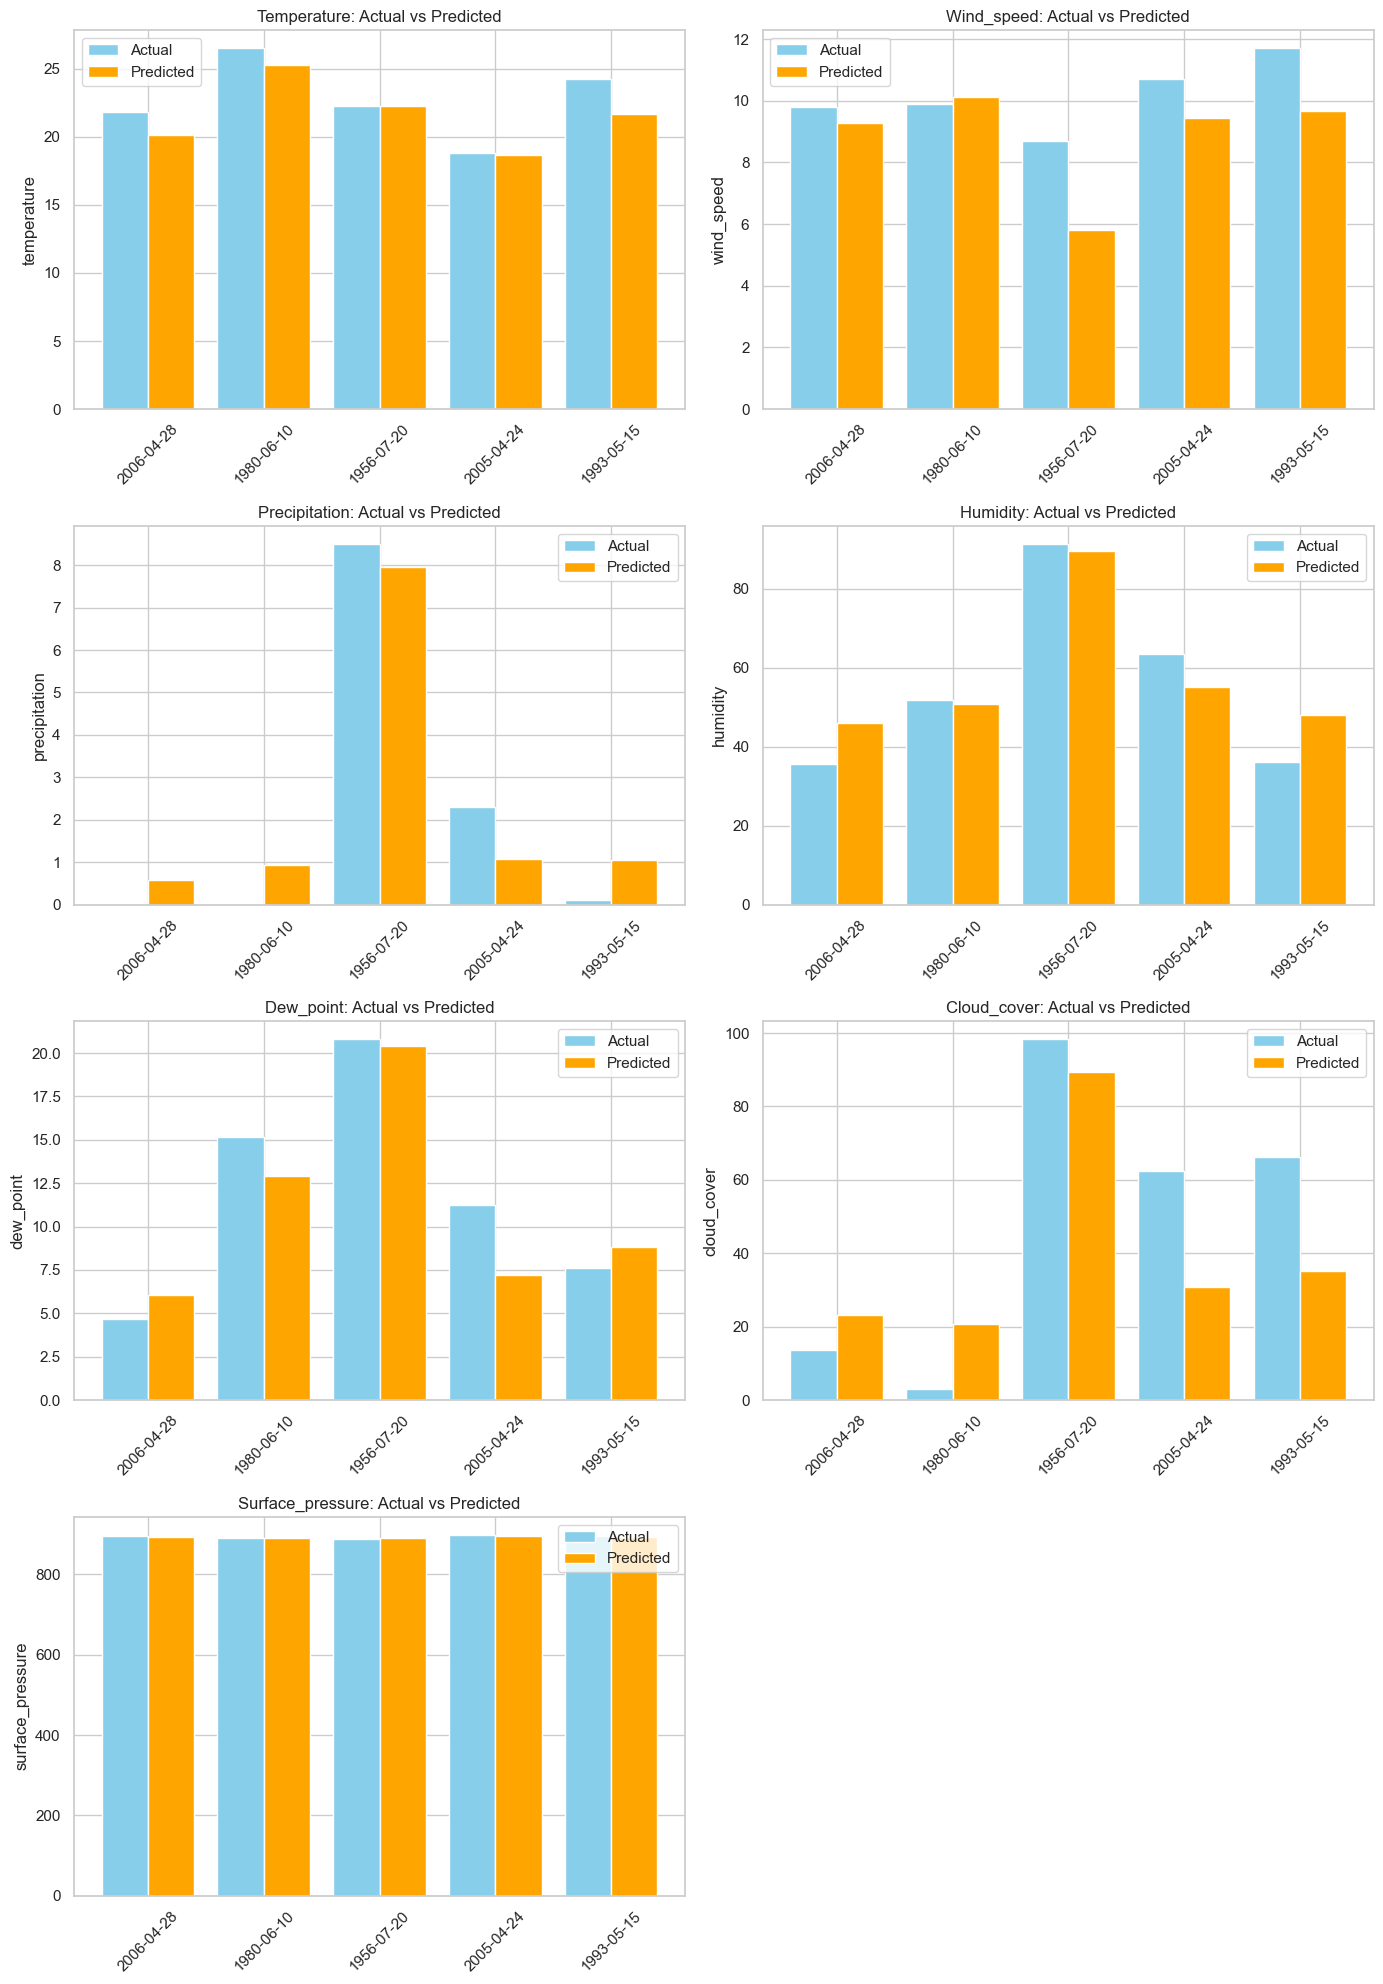

In [19]:
import matplotlib.pyplot as plt
import math

# Dynamically determine rows/cols based on number of features
num_features = len(target_features)
cols = 2
rows = math.ceil(num_features / cols)

fig, axs = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axs = axs.flatten()  # Flatten in case it's 2D

for i, col in enumerate(target_features):
    model = trained_models[col]
    pred_vals = model.predict(X_sample_scaled)
    true_vals = sample_df[col].values

    axs[i].bar(np.arange(len(true_vals)) - 0.2, true_vals, width=0.4, label='Actual', color='skyblue')
    axs[i].bar(np.arange(len(pred_vals)) + 0.2, pred_vals, width=0.4, label='Predicted', color='orange')
    axs[i].set_title(f"{col.capitalize()}: Actual vs Predicted")
    axs[i].set_xticks(np.arange(len(true_vals)))
    axs[i].set_xticklabels(
        [f"{int(y)}-{int(m):02d}-{int(d):02d}" for y, m, d in zip(sample_df['year'], sample_df['month'], sample_df['day'])],
        rotation=45
    )
    axs[i].set_ylabel(col)
    axs[i].legend()

# Hide any unused subplots if present
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

In [5]:
import os
import requests
import pandas as pd
from datetime import datetime, timedelta, timezone

# File path
file_path = "C:/Users/ADMIN/Downloads/combined_daily_weather_dataset.csv"

# Determine date range
try:
    df_existing = pd.read_csv(file_path, parse_dates=["time"])
    last_date = df_existing['time'].max().date()
    print(f"Last recorded date: {last_date}")
except (FileNotFoundError, ValueError, KeyError):
    print("No 'time' column found in existing data. Assuming empty dataset.")
    df_existing = pd.DataFrame()
    last_date = datetime(1947, 1, 1).date()

# Fetch data from the next day
start_date = last_date + timedelta(days=1)
today = datetime.now(timezone.utc).date()

if start_date > today:
    print("✅ Dataset is already up to date!")
else:
    print(f"Fetching new data from {start_date} to {today}...")

    url = (
        f"https://archive-api.open-meteo.com/v1/archive?"
        f"latitude=31.77585582314028&longitude=76.98625742910637"
        f"&start_date={start_date}&end_date={today}"
        f"&daily=temperature_2m_max,temperature_2m_min"
        f"&hourly=temperature_2m,wind_speed_10m,wind_direction_10m,"
        f"precipitation,relative_humidity_2m,dew_point_2m,"
        f"cloud_cover,surface_pressure"
        f"&timezone=auto"
    )

    response = requests.get(url)
    data = response.json()

    if "hourly" in data:
        hourly_df = pd.DataFrame(data["hourly"])
        hourly_df["time"] = pd.to_datetime(hourly_df["time"])
    else:
        hourly_df = pd.DataFrame()

    if "daily" in data:
        daily_df = pd.DataFrame(data["daily"])
        daily_df["time"] = pd.to_datetime(daily_df["time"])
    else:
        daily_df = pd.DataFrame()

    # Merge if both are available
    if not hourly_df.empty and not daily_df.empty:
        # Merge on date (keep hourly granularity)
        hourly_df["date"] = hourly_df["time"].dt.date
        daily_df["date"] = daily_df["time"].dt.date
        combined_df = pd.merge(hourly_df, daily_df, on="date", suffixes=("_hourly", "_daily"))
        combined_df.drop(columns=["date"], inplace=True)
    elif not hourly_df.empty:
        combined_df = hourly_df
    elif not daily_df.empty:
        combined_df = daily_df
    else:
        print("❌ No new data found in response.")
        combined_df = pd.DataFrame()

    # Save combined
    if not combined_df.empty:
        if df_existing.empty:
            combined_df.to_csv(file_path, index=False)
            print(f"✅ Saved new data to {file_path}")
        else:
            df_updated = pd.concat([df_existing, combined_df], ignore_index=True)
            df_updated.drop_duplicates(subset=["time"], keep="last", inplace=True)
            df_updated.to_csv(file_path, index=False)
            print(f"✅ Appended and saved updated data to {file_path}")

No 'time' column found in existing data. Assuming empty dataset.
Fetching new data from 1947-01-02 to 2025-04-12...
❌ No new data found in response.
